In [1]:
import numpy as np
from torchvision.models import resnet
import torchvision.transforms as transforms
from torchvision import datasets

import torch
from captum.attr import Occlusion

import kagglehub

import os

from utils.plot import plot_random_six_images, plot_idx_labeled, plot_occlusion
from utils.model_eval import test_on_given_idx

#SEEDS
np.random.seed(23)
torch.manual_seed(23)

/home/franio/Desktop/Explainable_AI/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
# Download latest version
DATA_PATH = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
IMG_PATH = os.path.join(DATA_PATH, "images", "Images")
ANNOTATION_PATH = os.path.join(DATA_PATH, "annotations", "Annotations")

print("Path to dataset files:", DATA_PATH)

dataset = datasets.ImageFolder(root=IMG_PATH)

Path to dataset files: /home/franio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


# Transforms

In [3]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([transforms.Resize((224,224)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean, std)])

# Images and prediction

## Example data

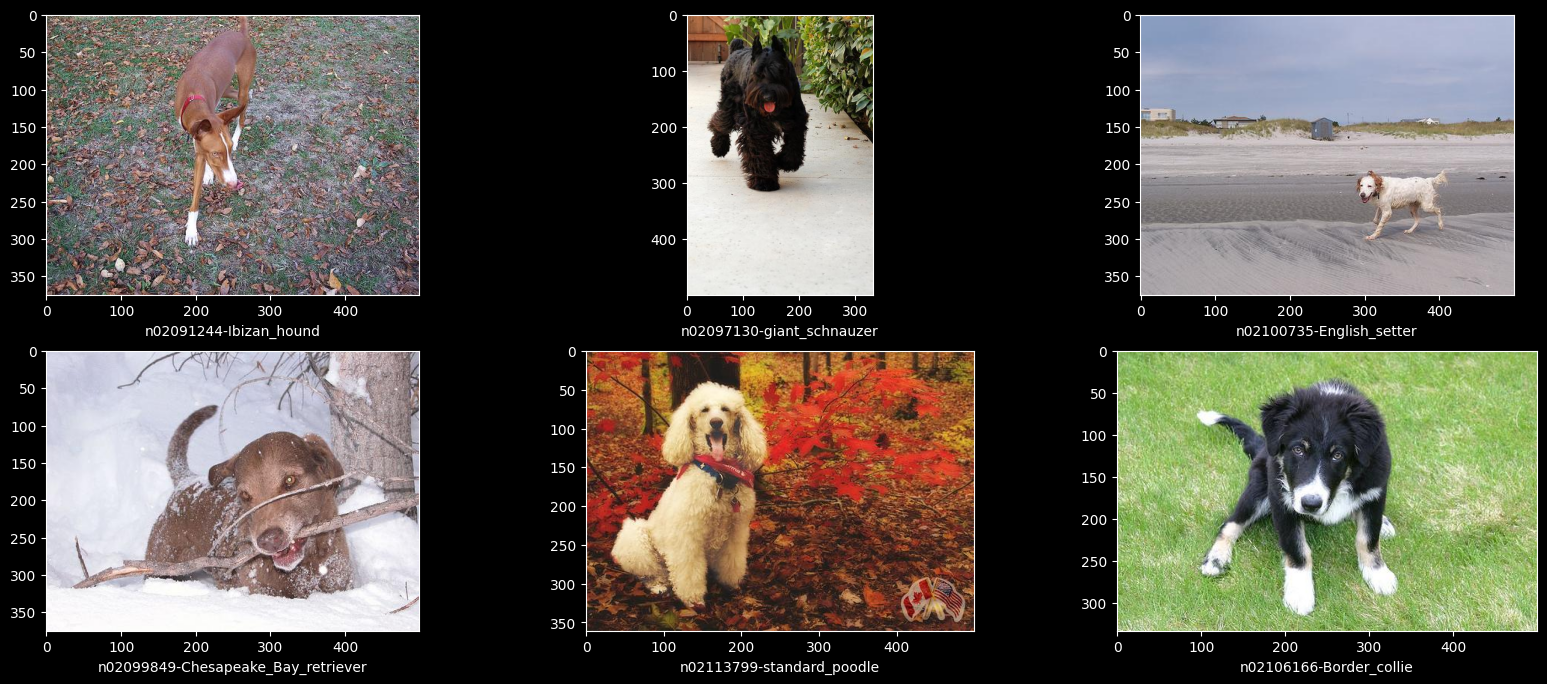

In [4]:
idx = plot_random_six_images(dataset, dataset.classes)


## Loading model and predictions

In [5]:
MODEL_NAME = 'resnet18_dogs_5_epochs'

net_model = resnet.resnet18()
net_model.load_state_dict(torch.load(os.path.join('models', f"{MODEL_NAME}.pth"), weights_only=True))

preds, df = test_on_given_idx(dataset, net_model,transform, idx=idx)

df

,Idx,True_Label,Predicted_Label
0,4036,n02091244-Ibizan_hound,n02091244-Ibizan_hound
1,8382,n02097130-giant_schnauzer,n02097130-giant_schnauzer
2,10856,n02100735-English_setter,n02100735-English_setter
3,10457,n02099849-Chesapeake_Bay_retriever,n02109047-Great_Dane
4,19889,n02113799-standard_poodle,n02113624-toy_poodle
5,14016,n02106166-Border_collie,n02106166-Border_collie


array([ 4036,  8382, 10856, 10457, 19889, 14016])

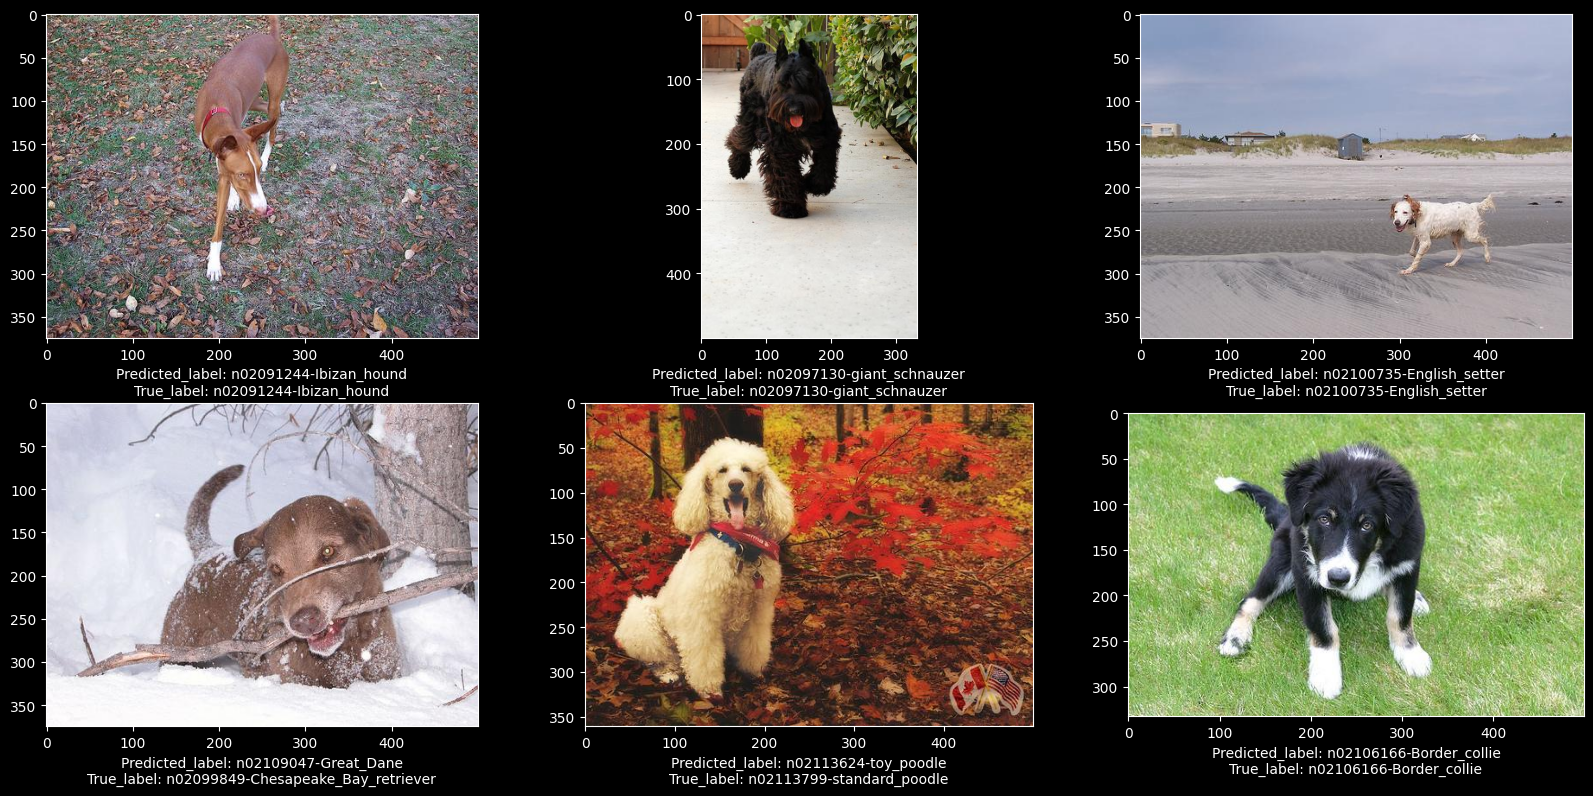

In [6]:
plot_idx_labeled(idx,preds,dataset)

# Occlusion map

In [ ]:
Occ = Occlusion(net_model)

plot_occlusion(idx, preds, dataset, Occ.attribute, transform)